In [17]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [18]:
STAT_PATH = "../experiments"
SPEED_STATISTICS_NAME = os.path.join("exp", "speed_statistics")
EXP_NAME = "run_"
BINS_COUNT = 100


In [19]:
def read_hosts_power(file_path):
    df = pd.read_csv(file_path, header=None, names=["host_power_gflops"])
    return df["host_power_gflops"].dropna().astype(float)


def build_power_histogram(values, bins_count, max_power):
    bin_edges = np.linspace(0.0, max_power, bins_count + 1)
    counts, _ = np.histogram(values, bins=bin_edges)
    return counts, bin_edges


def plot_hosts_power(ax, counts, bin_edges, label):
    bin_width = bin_edges[1] - bin_edges[0]
    ax.bar(bin_edges[:-1], counts, width=bin_width * 0.9, align="edge", alpha=0.6, label=label)
    ax.set_title("Диаграмма распределений хостов по мощностям")
    ax.set_xlabel("Мощность хоста, гфлопс")
    ax.set_ylabel("Число хостов, ед")


def configure_power_axis(ax, max_power):
    ax.set_xlim(0, max_power)
    ax.grid(True, axis="y", linestyle="--", linewidth=0.5)


found ['run_0001']


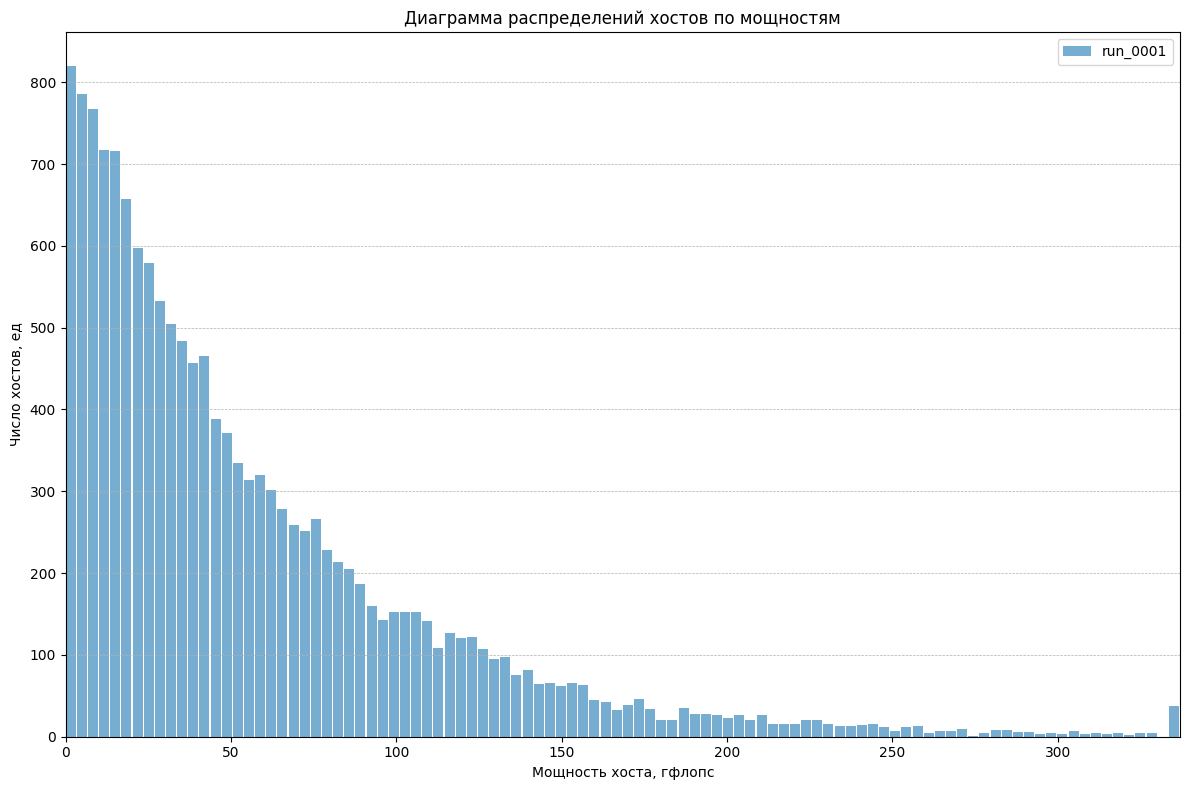

In [20]:
folders = sorted(
    folder
    for folder in os.listdir(STAT_PATH)
    if os.path.isdir(os.path.join(STAT_PATH, folder)) and folder.startswith(EXP_NAME)
)

if not folders:
    print(f"there is no folders in {STAT_PATH}")
else:
    print(f"found {folders}")

datasets = []

for folder in folders:
    full_path = os.path.join(STAT_PATH, folder)
    speed_statistics_path = os.path.join(full_path, SPEED_STATISTICS_NAME)

    if not os.path.exists(speed_statistics_path):
        print(f"skip {folder}: {SPEED_STATISTICS_NAME} not found")
        continue

    values = read_hosts_power(speed_statistics_path)
    if values.empty:
        print(f"skip {folder}: {SPEED_STATISTICS_NAME} is empty")
        continue

    datasets.append((folder, values))

if not datasets:
    print("there is no speed statistics to plot")
else:
    max_power = max(values.max() for _, values in datasets)
    fig, ax = plt.subplots(figsize=(12, 8))

    for folder, values in datasets:
        counts, bin_edges = build_power_histogram(values, BINS_COUNT, max_power)
        plot_hosts_power(ax, counts, bin_edges, folder)

    configure_power_axis(ax, max_power)
    ax.legend()
    plt.tight_layout()
    plt.show()
